In [1]:
import os
import sys
sys.path.append('/home/royhirsch/conformal/v3')

from ml_collections import config_dict
import logging
import pandas as pd
import pickle
import torch
import torch.nn as nn
import numpy as np
from sklearn.model_selection import train_test_split
from scipy.special import softmax
import torchcp
from data_config import get_config
from conformal_modules import APS, RAPS, Naive, SAPS, platt_scale, residual_conformal_score

In [2]:
config = get_config('cifar100_resnet56') # cifar100_resnet56, imagenet1k_resnet50
config.par_calib = 0.5
config.num_calib = int(config.num_samples * config.par_calib)
config.plat_scale = True
config.seed = 4
config.estimation_method_name = 'max' # max / mean
config.randomized = True
config.no_zero_size_sets = True
config.alpha = 0.1

# Funcs

In [3]:
with open(config.file_name, 'rb') as file:
    data = pickle.load(file)

labels_eval, labels_calib, scores_eval, scores_calib = train_test_split(
    data["labels"], data["preds"], test_size=config.par_calib, random_state=42
)
if config.plat_scale:
    t = platt_scale(scores_calib, labels_calib, max_iters=100, lr=0.01, epsilon=0.005)
else:
    t = 1.0

print(f"Temperature: {t}")
scores_calib = softmax(scores_calib / t, axis=1)
scores_eval = softmax(scores_eval / t, axis=1)
eval_data = {"labels": labels_eval, "scores": scores_eval}
calib_data = {"labels": labels_calib, "scores": scores_calib}


  8%|▊         | 8/100 [00:00<00:09,  9.20it/s]

Temperature: 1.7361743450164795


# Baselines

In [4]:
n = len(calib_data["labels"])

conf_score = RAPS(0.01, randomized=True, no_zero_size_sets=config.no_zero_size_sets, seed=config.seed)
cal_scores = conf_score.get_scores(calib_data["scores"], calib_data["labels"])
baseline_qhat = np.quantile(
    cal_scores, np.ceil((n + 1) * (1 - config.alpha)) / n, interpolation="higher"
)
prediction_sets = conf_score.get_sets(eval_data["scores"], baseline_qhat)

empirical_coverage = prediction_sets[
    np.arange(prediction_sets.shape[0]), eval_data["labels"]
].mean()

baseline_mets = {
    "size": prediction_sets.sum(1).mean(),
    "coverage": empirical_coverage,
}

print('Baseline mets:')
for key, value in baseline_mets.items():
    print(f"{key}: {value:.4f}")
print('Qhat: {:.4f}'.format(baseline_qhat))


Baseline mets:
size: 4.6836
coverage: 0.9260
Qhat: 0.9272


# Ours method

In [5]:
def get_estimated_score(scores, method, conf_score):
    if method == 'max':
        scores = conf_score.get_scores(scores, scores.argmax(1))
        return scores 
    
    elif method == 'mean':
        cal_pi = scores.argsort(1)[:, ::-1]
        cal_srt = np.take_along_axis(scores, cal_pi, axis=1).cumsum(axis=1)
        cal_softmax_correct_class = np.take_along_axis(cal_srt, cal_pi.argsort(axis=1), axis=1)
        return (cal_softmax_correct_class * scores).sum(1)
    else:
        raise ValueError('Unknown method')


In [6]:
results = residual_conformal_score(calib_data, eval_data, conf_score, config.alpha)
residuales = results['residuales']
qhat = results['qhat']
qhat = results['qhat']
print('Residuales: mean: {:.3f} std: {:.3f} min: {:.3f} max: {:.3f}'.format(residuales.mean(), residuales.std(), residuales.min(), residuales.max()))
print('Qhat: {:.4f}'.format(qhat))

empirical_coverage = results['val_prediction_sets'][np.arange(results['val_prediction_sets'].shape[0]), eval_data["labels"]].mean()

ours_mets = {"size": results['val_prediction_sets'].sum(1).mean(), "coverage": empirical_coverage}

print('Ours mets:')
for key, value in ours_mets.items():
    print(f"{key}: {value:.4f}")


/var/tmp/ipykernel_3311745/1954323512.py:1: DeprecationWarning: the `interpolation=` argument to quantile was renamed to `method=`, which has additional options.
Users of the modes 'nearest', 'lower', 'higher', or 'midpoint' are encouraged to review the method they used. (Deprecated NumPy 1.22)
  results = residual_conformal_score(calib_data, eval_data, conf_score, config.alpha)


Residuales: mean: 0.095 std: 0.172 min: 0.000 max: 1.000
Qhat: 0.3735
Ours mets:
size: 7.7412
coverage: 0.9042


In [7]:
softmax_scores = calib_data["scores"]
labels = calib_data["labels"]

k_reg = 5
lam_reg = 0.01
reg_vec = np.array(k_reg * [0, ] + (softmax_scores.shape[1] - k_reg) * [lam_reg, ])[None, :]
n = softmax_scores.shape[0]
cal_pi = softmax_scores.argsort(1)[:, ::-1]
cal_srt = np.take_along_axis(softmax_scores, cal_pi, axis=1)
cal_srt_reg = cal_srt + reg_vec
cal_L = np.where(cal_pi == labels[:,None])[1]
cal_scores = cal_srt_reg.cumsum(axis=1)[np.arange(n),cal_L] - np.random.rand(n) * cal_srt_reg[np.arange(n), cal_L]


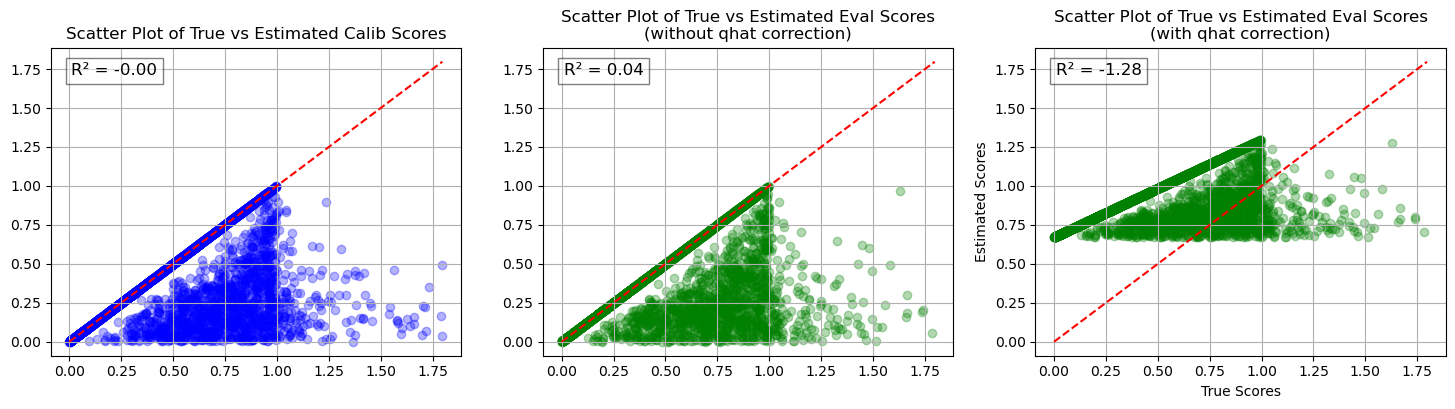

Text(0.5, 1.0, 'Estimated eval scores')

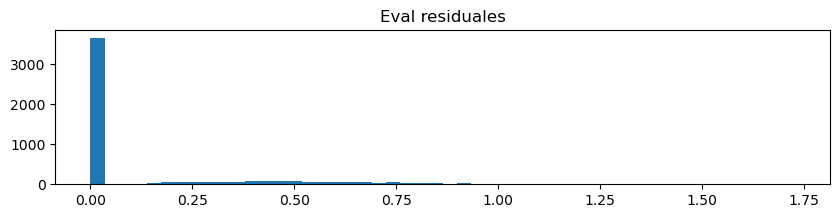

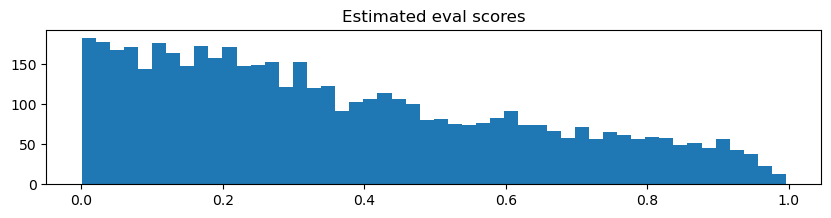

In [8]:
# debug #
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

cal_scores_est = results["cal_scores_est"]
cal_scores_true = results["cal_scores_true"]
max_val = cal_scores_true.max()

val_scores_est = results["val_scores_est"]
val_scores_true = results["val_scores_true"]
val_scores_est_w_qhat = results["val_scores_est_w_qhat"]
fig, ax = plt.subplots(1, 3, figsize=(18, 4))

ax[0].scatter(cal_scores_true, cal_scores_est, color='blue', alpha=0.3)
ax[0].set_title('Scatter Plot of True vs Estimated Calib Scores')
r2 = r2_score(cal_scores_true, cal_scores_est)
ax[0].text(0.05, 0.95, f'R² = {r2:.2f}', transform=ax[0].transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[0].plot([0, max_val], [0, max_val], 'r--')
ax[0].grid(True)

ax[1].scatter(val_scores_true, val_scores_est, color='green', alpha=0.3)
ax[1].set_title('Scatter Plot of True vs Estimated Eval Scores\n(without qhat correction)')
r2 = r2_score(val_scores_true, val_scores_est)
ax[1].text(0.05, 0.95, f'R² = {r2:.2f}', transform=ax[1].transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[1].plot([0, max_val], [0, max_val], 'r--')
ax[1].grid(True)

ax[2].scatter(val_scores_true, val_scores_est_w_qhat, color='green', alpha=0.3)
ax[2].set_title('Scatter Plot of True vs Estimated Eval Scores\n(with qhat correction)')
r2 = r2_score(val_scores_true, val_scores_est_w_qhat)
ax[2].text(0.05, 0.95, f'R² = {r2:.2f}', transform=ax[2].transAxes, 
         fontsize=12, verticalalignment='top', bbox=dict(facecolor='white', alpha=0.5))
plt.xlabel('True Scores')
plt.ylabel('Estimated Scores')
ax[2].plot([0, max_val], [0, max_val], 'r--')
ax[2].grid(True)
plt.show()

plt.figure(figsize=(10, 2))
_ = plt.hist(val_scores_true - val_scores_est, bins=50)
plt.title('Eval residuales')

plt.figure(figsize=(10, 2))
_ = plt.hist(val_scores_est, bins=50)
plt.title('Estimated eval scores')

# Results

In [9]:
import pandas as pd

df = pd.DataFrame(columns=['Method', 'Size', 'Coverage'])
df.loc[0] = ['Baseline', baseline_mets['size'], baseline_mets['coverage']]
df.loc[1] = ['Ours', ours_mets['size'], ours_mets['coverage']]
print(df)

     Method    Size  Coverage
0  Baseline  4.6836    0.9260
1      Ours  7.7412    0.9042
